In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [2]:
groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = [f"{group}_{t}" for group in groups for t in range(8)]
columns.append("target")

df = pd.read_csv(
    "TomsHardware.data",
    header=None,
    names=columns
)

df["target_log"] = np.log1p(df["target"])
print(df.shape)
#df.head(20)

(28179, 98)


In [8]:

df["target_log"] = np.log1p(df["target"])


X = df.drop(
    ["target", "target_log"] + [col for col in df.columns if col.startswith("ND_")],
    axis=1
)
y = df["target_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(rmse, mae, r2)

1.1445222112715696 0.8214722194178647 0.7674198201829746


  base_feature  importance
2        AS_NA    0.346231
0          ADL    0.287174
9          NAD    0.174153
3       AS_NAC    0.064594
6           CS    0.055686


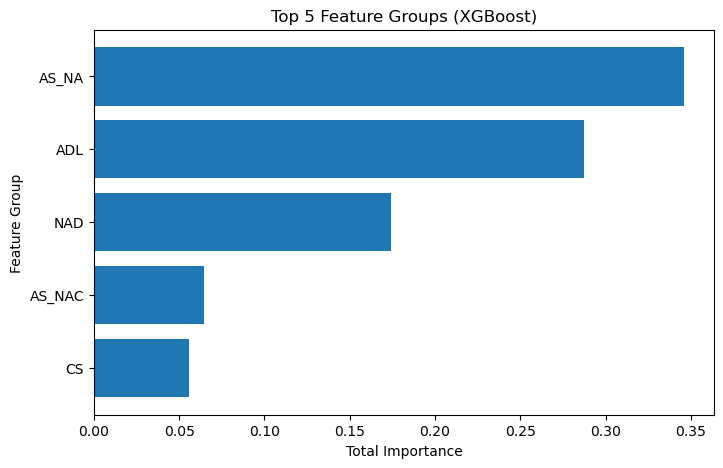

In [14]:
importances = model.feature_importances_
feature_names = X.columns 


feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp["base_feature"] = feat_imp["feature"].apply(lambda x: x.rsplit("_", 1)[0])

grouped_importance = ( feat_imp.groupby("base_feature")["importance"].sum().reset_index())
grouped_importance = grouped_importance.sort_values(by="importance",ascending=False)


top_grouped = grouped_importance.head(5)

print(top_grouped)

plt.figure(figsize=(8, 5))
plt.barh(top_grouped["base_feature"], top_grouped["importance"])
plt.gca().invert_yaxis()

plt.title("Top 5 Feature Groups (XGBoost)")
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")

plt.show()